# Regression using Artificial Neural Networks

in this example we will use Keras to predict wages based on various professional and demographic factors.

In [1]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import tensorflow as tf
import matplotlib.pyplot as plt


pd.set_option('display.float_format', '{:.4f}'.format)

sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

imports ok


##Load Data

In [3]:
#connect google drive to this colab
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
# Load data file
data = pd.read_csv('/content/gdrive/MyDrive/Machine Learning_Datasets for design/DATASET_wages.csv')
pd.options.display.max_columns = None

print(data)

     wage_per_hour  union  education_yrs  experience_yrs  age  female  marr  \
0           5.1000      0              8              21   35       1     1   
1           4.9500      0              9              42   57       1     1   
2           6.6700      0             12               1   19       0     0   
3           4.0000      0             12               4   22       0     0   
4           7.5000      0             12              17   35       0     1   
..             ...    ...            ...             ...  ...     ...   ...   
529        11.3600      0             18               5   29       0     0   
530         6.1000      0             12              33   51       1     1   
531        23.2500      1             17              25   48       1     1   
532        19.8800      1             12              13   31       0     1   
533        15.3800      0             16              33   55       0     1   

     south  manufacturing  construction  
0        

In [5]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   wage_per_hour   534 non-null    float64
 1   union           534 non-null    int64  
 2   education_yrs   534 non-null    int64  
 3   experience_yrs  534 non-null    int64  
 4   age             534 non-null    int64  
 5   female          534 non-null    int64  
 6   marr            534 non-null    int64  
 7   south           534 non-null    int64  
 8   manufacturing   534 non-null    int64  
 9   construction    534 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 41.8 KB
None


In [6]:
for colname, col in data.items():
  print(colname, "min_val", col.min(), "max_val", col.max())

wage_per_hour min_val 1.0 max_val 44.5
union min_val 0 max_val 1
education_yrs min_val 2 max_val 18
experience_yrs min_val 0 max_val 55
age min_val 18 max_val 64
female min_val 0 max_val 1
marr min_val 0 max_val 1
south min_val 0 max_val 1
manufacturing min_val 0 max_val 1
construction min_val 0 max_val 1


In [7]:
data.describe()

,wage_per_hour,union,education_yrs,experience_yrs,age,female,marr,south,manufacturing,construction
count,534.0000,534.0000,534.0000,534.0000,534.0000,534.0000,534.0000,534.0000,534.0000,534.0000
mean,9.0241,0.1798,13.0187,17.8221,36.8333,0.4588,0.6554,0.2921,0.1854,0.0449
std,5.1391,0.3844,2.6154,12.3797,11.7266,0.4988,0.4757,0.4552,0.3890,0.2074
min,1.0000,0.0000,2.0000,0.0000,18.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,5.2500,0.0000,12.0000,8.0000,28.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,7.7800,0.0000,12.0000,15.0000,35.0000,0.0000,1.0000,0.0000,0.0000,0.0000
75%,11.2500,0.0000,15.0000,26.0000,44.0000,1.0000,1.0000,1.0000,0.0000,0.0000
max,44.5000,1.0000,18.0000,55.0000,64.0000,1.0000,1.0000,1.0000,1.0000,1.0000


we can see that some predictors are binary, while others are not

In [8]:
data_binary = data[["union", "female", "marr", "south", "manufacturing", "construction"]]

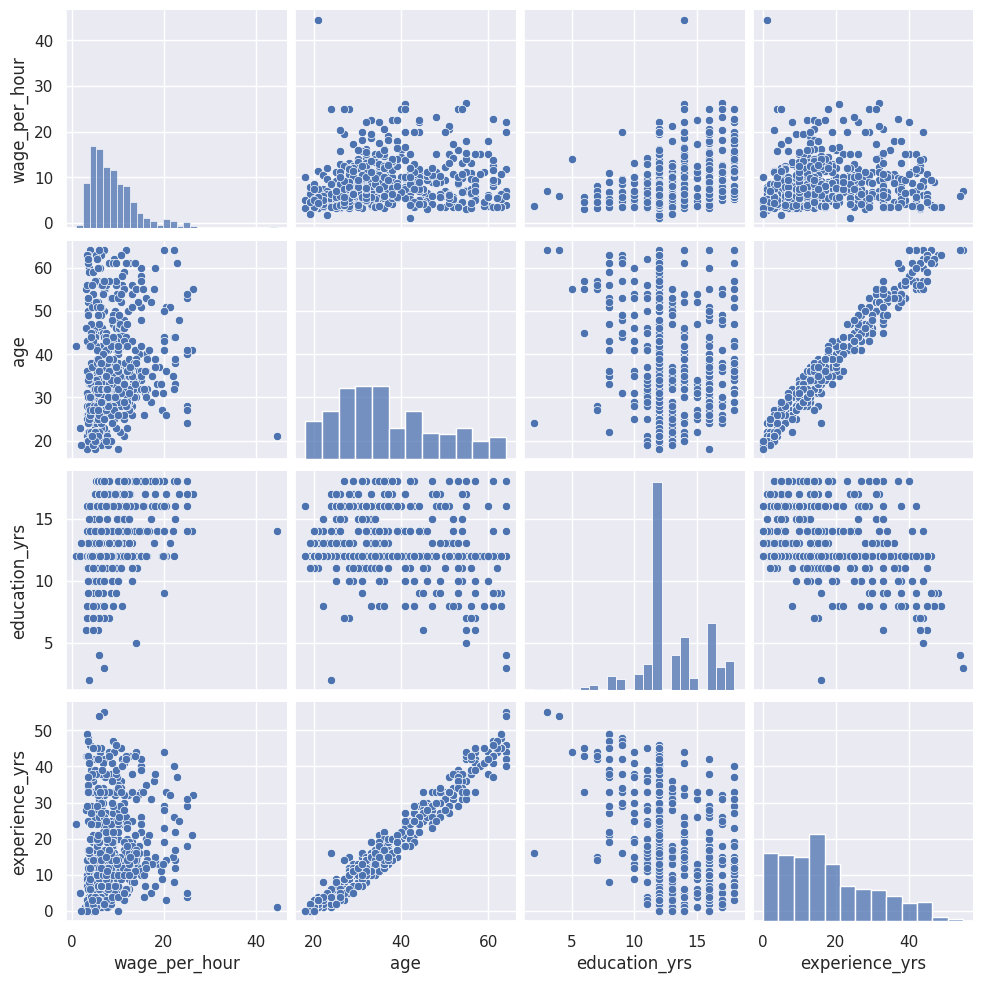

In [9]:
data_numerical = data[["wage_per_hour", "age", "education_yrs", "experience_yrs"]]
sns.pairplot(data_numerical)

We can see there is a direct relationship between age and experience, but not so much between wage and education, there is a non-linearity

##Prepare Data

**NORMALIZE INPUTS**

In [10]:
#same code as last time

#declare features
X = data.iloc[:,1:-1]

# Load and instantiate a StandardSclaer
from sklearn.preprocessing import StandardScaler
scalerX = StandardScaler()

# Apply the scaler to our X-features
X_scaled = scalerX.fit_transform(X)

print(X_scaled.shape)

(534, 8)


In [11]:
#declare regression target
y = data.loc[:,"wage_per_hour"].to_numpy()

y = y.reshape(-1, 1)

from sklearn.preprocessing import MinMaxScaler
scalerY = MinMaxScaler()

#In this case it makes sense to use MinMax scaling because the wage seems like a relative range
# Apply the scaler to our Y-features
y_scaled = scalerY.fit_transform(y)

print(y_scaled.shape)


(534, 1)


**SPLIT INTO TRAIN AND TEST**

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size = 0.2, random_state = 21)

In [13]:
#visualize our data
#we can see that scikitlearn doesnt care if it is a dataframe or a numpy array, because they all function on the same way
print("TRAIN", "input", X_train.shape, "output", y_train.shape)
print("TEST", "input", X_test.shape, "output", y_test.shape)


TRAIN input (427, 8) output (427, 1)
TEST input (107, 8) output (107, 1)


#Build model

From the cheatSheet
Regression between 0 and 1>>
      activation = relu for hidden layers / sigmoid for final layer
      loss = mean squared error
      optimizer = adam
      input from data, is 8 columns
      output is 1 value prediction

In [14]:
# Instantiate a sequential model
model = tf.keras.models.Sequential()
n_cols = X_scaled.shape[1]

model.add(tf.keras.layers.Dense(4, input_shape=(n_cols,), activation='relu'))
model.add(tf.keras.layers.Dense(2, activation='relu'))

# Add a dense layer with 1 value output
model.add(tf.keras.layers.Dense(1, activation= "sigmoid"))

# Compile your model
model.compile(optimizer = "adam", loss = "mean_squared_error")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

#Train model

In [16]:
# Fit your model to the training data for 200 epochs
#we assign this to history variable so we can plot the training data
history = model.fit(X_train,y_train,epochs=500, validation_split=0.2)

Epoch 1/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0917 - val_loss: 0.0879
Epoch 2/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0875 - val_loss: 0.0840
Epoch 3/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0834 - val_loss: 0.0801
Epoch 4/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0793 - val_loss: 0.0762
Epoch 5/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0751 - val_loss: 0.0724
Epoch 6/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0710 - val_loss: 0.0685
Epoch 7/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0669 - val_loss: 0.0646
Epoch 8/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0628 - val_loss: 0.0608
Epoch 9/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0590 - val_loss: 0.0570
Epoch 10/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0551 - val_loss: 0.0535
Epoch 11/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0516 - val_loss: 0.0501
Epoch 12/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

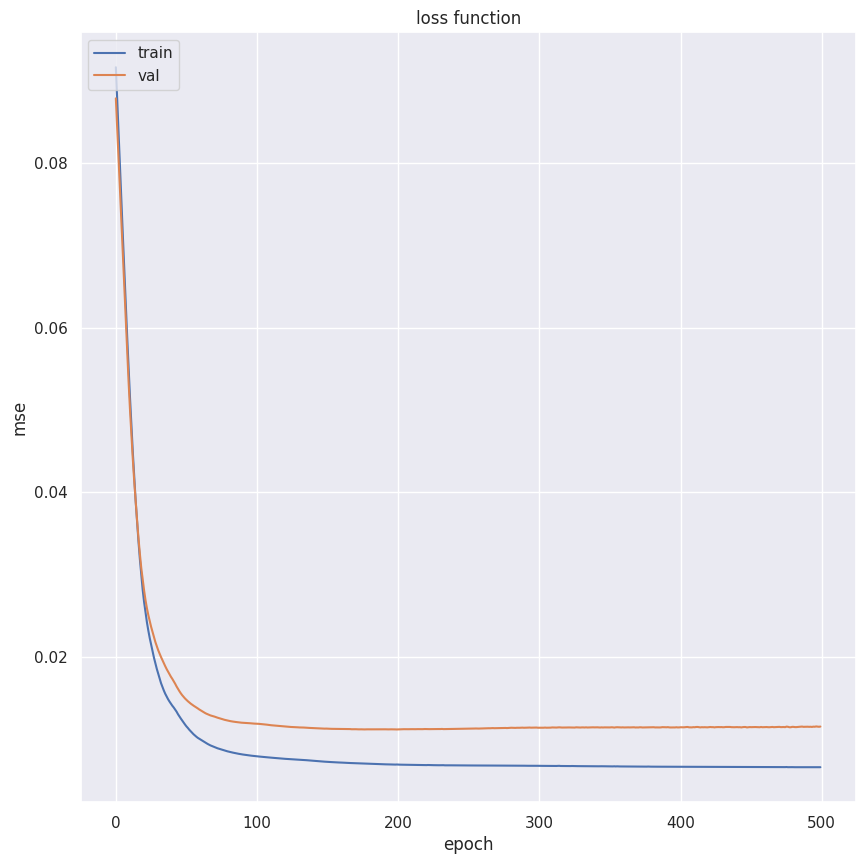

In [17]:
# summarize history for accuracy
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss function')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

#Evaluate model on test data



In [18]:
# Evaluate your model accuracy on the test data
loss_test = model.evaluate(X_test,y_test)

# Print accuracy
print('mse_test:', loss_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0192
mse_test: 0.01916547492146492


we can see the model is again slightly overfitting, but what does this translate in terms of USD accuracy of our prediction?

#Plot error


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


Text(0, 0.5, 'y_pred (usd/h)')

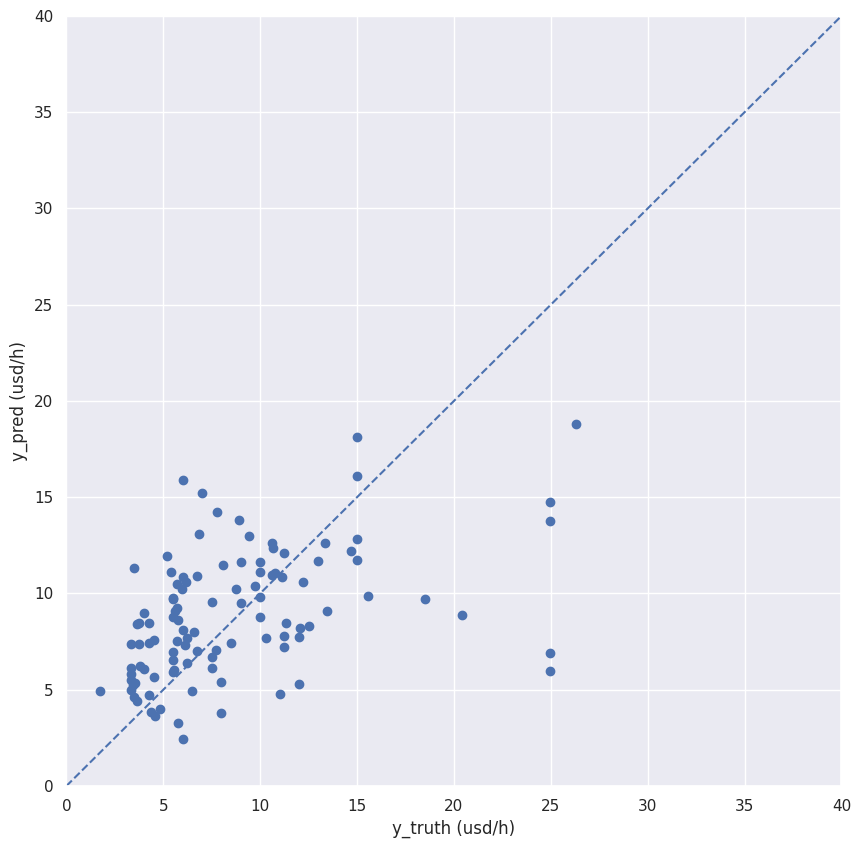

In [19]:
y_pred = scalerY.inverse_transform(model.predict(X_test))
y_truth = scalerY.inverse_transform(y_test)

plt.scatter(y_truth,y_pred)
plt.ylim((0,40))
plt.xlim((0,40))
plt.axline((0,0), slope = 1, ls="--")


plt.xlabel("y_truth (usd/h)")
plt.ylabel("y_pred (usd/h)")


In [20]:
def plot_comparison(x_val, pred, truth, xlab, ylab):
  fig, ax1 = plt.subplots(figsize = (10,10))
  ax1.plot(x_val, truth, color = "red", label = "truth",linestyle='None', marker = "o", markersize = 5)
  ax1.plot(x_val, pred, color = "blue", label = "pred",linestyle='None', marker = "o", markersize = 4, alpha = 0.5)

  ax1.set_xlabel(xlab)
  ax1.set_ylabel(ylab)
  ax1.legend()
  plt.title('Prediction Comparison')
  plt.show()

[30. 29. 22. 37. 34. 38. 28. 38. 20. 29. 21. 54. 30. 52. 33. 53. 32. 30.
 29. 47. 53. 31. 59. 25. 34. 57. 26. 50. 28. 41. 26. 30. 52. 48. 29. 54.
 60. 32. 56. 34. 31. 30. 25. 29. 42. 28. 36. 41. 43. 20. 37. 50. 25. 30.
 27. 23. 29. 38. 33. 28. 27. 35. 27. 60. 30. 36. 47. 57. 51. 34. 56. 28.
 41. 36. 36. 34. 23. 57. 35. 37. 32. 40. 24. 27. 59. 20. 25. 19. 26. 39.
 32. 38. 40. 21. 47. 18. 42. 25. 62. 49. 55. 26. 28. 25. 27. 31. 34.]


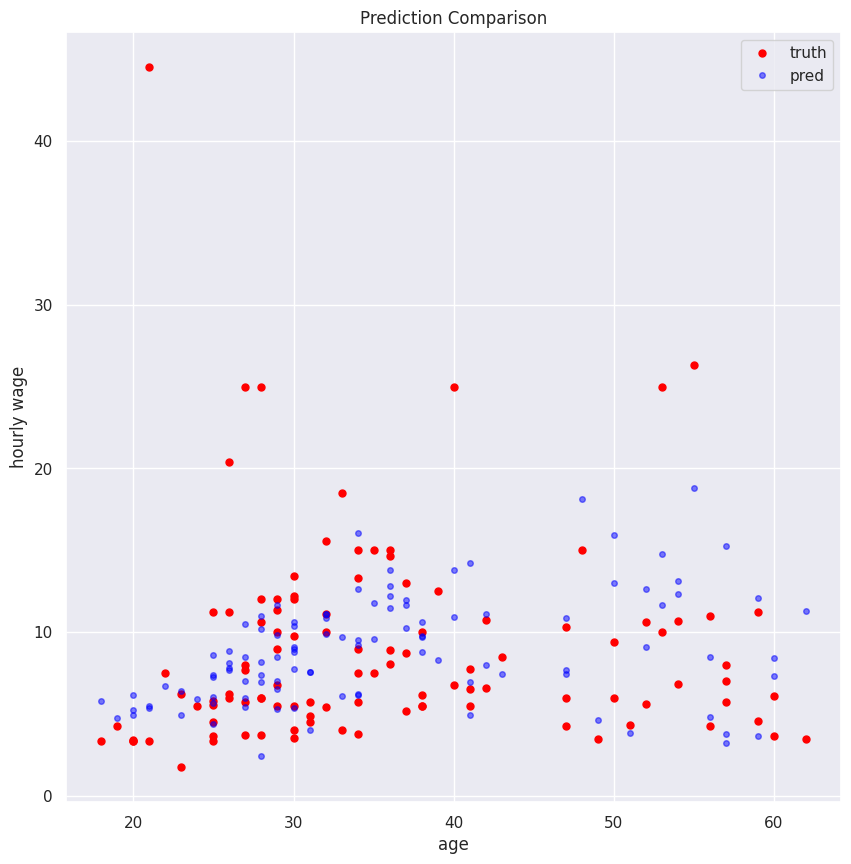

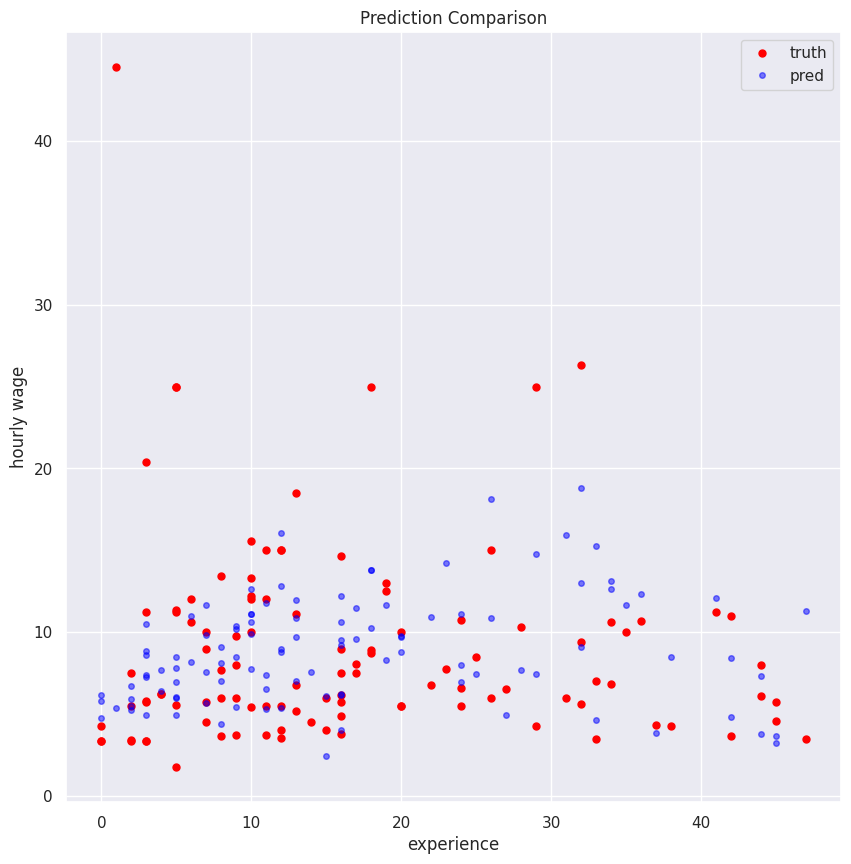

In [21]:
age_test = (scalerX.inverse_transform(X_test)[:,3])
print(age_test)

exp_test = (scalerX.inverse_transform(X_test)[:,2])

plot_comparison(age_test, y_pred, y_truth, "age", "hourly wage")
plot_comparison(exp_test, y_pred, y_truth,  "experience", "hourly wage")

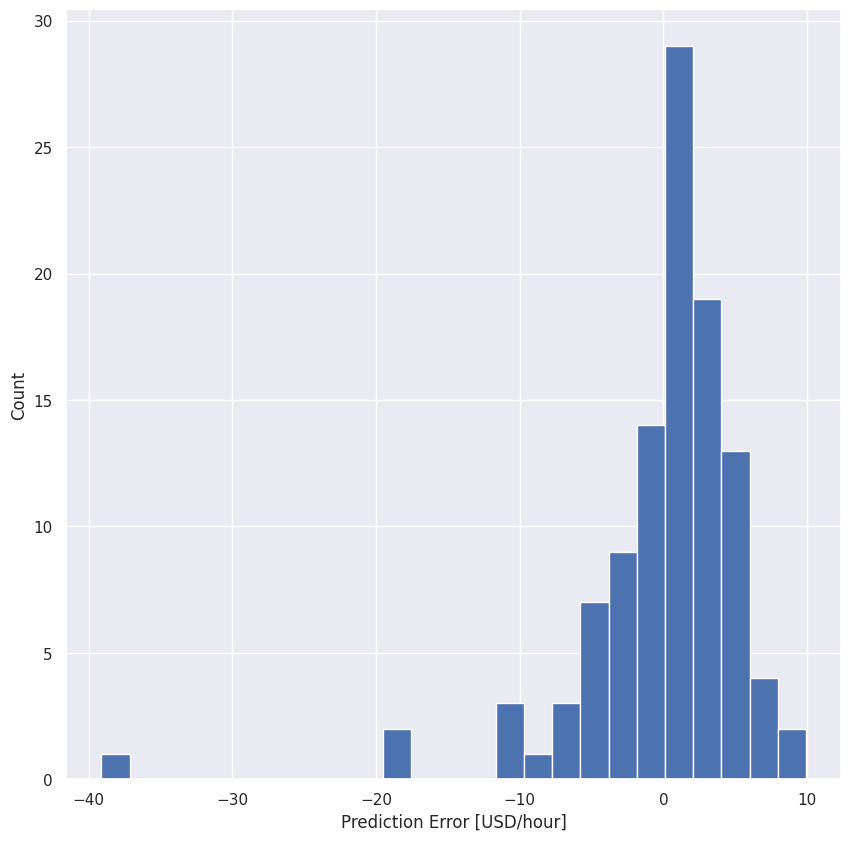

In [22]:
error = y_pred - y_truth
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [USD/hour]')
_ = plt.ylabel('Count')